
# Project 7 — 5G Throughput Prediction in a Dense Deployment

## Table of Contents

| Section | Description |
|---|---|
| 1. Setup | Install dependencies and import libraries |
| 2. Configuration & Dataset | Upload CSV, set hyperparameters, define column names |
| 3. Helper Functions | Metrics, preprocessing pipeline, feature engineering, split utilities |
| 4. Data Loading & Validation | Read CSV, check schema, display summary statistics |
| 5. Exploratory Data Analysis (EDA) | Throughput distribution, SINR correlation, spatial layout |
| 6. Preprocessing & Feature Engineering | Operator-device feature aggregation, distribution checks |
| 7. Train / Test Split | Per-user chronological split + eligible-user filtering |
| 8. Centralized Models | Random Forest and MLP with GridSearchCV |
| 9. Federated Learning — FedAvg | FedAvg training, convergence curve, 5-model comparison |
| 10. X-Sensitivity Experiment | Re-train RF & MLP for X ∈ {3, 5, 10, 20} |
| 11. Save Results | Export metrics to JSON and download |


> The only manual step is uploading (or mounting from Drive) the ACC Arena CSV file in **Section 2**.


## 1. Install and imports

In [ ]:
# Install the libraries needed by the notebook
# In Colab many of these are already available, but running this cell ensures compatibility
!pip install -q pandas numpy scikit-learn matplotlib seaborn torch

In [ ]:
# Standard Python utilities
import json
import copy
import time
import warnings
from collections import OrderedDict
from pathlib import Path
from statistics import mean

# Data handling
import numpy as np
import pandas as pd

# Plotting
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn components for preprocessing, training, tuning, and evaluation
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# PyTorch for the federated learning part
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
print('Imports completed successfully.')

Imports completed successfully.


## 2. Dataset upload and configuration

In [ ]:
# Upload the compact flat CSV file produced from the extract_acc_arena_subset.py script.
# This notebook expects a CSV with columns such as:
# venue, timestamp, user_id, traffic_type, ru_id, throughput_mbps, prb, bler, sinr_dl, sinr_ul, x, y, z

from google.colab import files

# uploaded  = files.upload()      # opens file picker
# fname     = next(iter(uploaded))
# DATA_PATH = Path('/content') / fname
# DATA_PATH.write_bytes(uploaded[fname])
# print(f'Uploaded → {DATA_PATH}')

# If using Google Drive instead, comment the block above and uncomment:
from google.colab import drive; drive.mount('/content/drive')
DATA_PATH = Path('/content/drive/MyDrive/Colab Notebooks/NDA Project/acc_arena_subset.csv')

Mounted at /content/drive


In [ ]:
# -----------------------------
# Global configuration
# -----------------------------
# You can edit these values before running the full notebook

# X = number of operator measurement devices.
# These are assumed to be users with IDs 0, 1, ..., X-1
X = 20

# Fraction of newest samples reserved for testing
TEST_FRACTION = 0.2

# Reproducibility seed
RANDOM_STATE = 42

# Federated Learning parameters
FEDERATED_ROUNDS = 20
LOCAL_EPOCHS = 3
LOCAL_MIN_SAMPLES = 50

# Values of X to test in the final sensitivity experiment
X_VALUES = [3, 5, 10, 20]

# Set random seeds so that results are reproducible
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

print('Configuration loaded.')
print('X =', X)
print('TEST_FRACTION =', TEST_FRACTION)
print('FEDERATED_ROUNDS =', FEDERATED_ROUNDS)
print('LOCAL_EPOCHS =', LOCAL_EPOCHS)
print('LOCAL_MIN_SAMPLES =', LOCAL_MIN_SAMPLES)

Configuration loaded.
X = 20
TEST_FRACTION = 0.2
FEDERATED_ROUNDS = 20
LOCAL_EPOCHS = 3
LOCAL_MIN_SAMPLES = 50


### Why LOCAL_MIN_SAMPLES = 50?

`LOCAL_MIN_SAMPLES` is the **minimum number of training samples** a user must have to participate in the federated learning simulation.

- With `TEST_FRACTION = 0.2`, roughly 80 % of each user's measurements go into training.
- A user with 50 training samples provides at least 63 samples total, enough for the local PyTorch model to converge stably over 3 epochs.
- Setting this threshold too low risks users with only 1–2 samples which would produce noisy local updates and destabilise FedAvg.
- Setting it too high (e.g., 200) would exclude the majority of users in this dataset and make the FL simulation unrealistic.


In [ ]:
# -----------------------------
# Column names used by the project
# -----------------------------

COL_VENUE = 'venue'
COL_TIMESTAMP = 'timestamp'
COL_USER_ID = 'user_id'
COL_TRAFFIC_TYPE = 'traffic_type'
COL_RADIO_UNIT = 'ru_id'
COL_THROUGHPUT = 'throughput_mbps'
COL_PRB = 'prb'
COL_BLER = 'bler'
COL_SINR_DL = 'sinr_dl'
COL_SINR_UL = 'sinr_ul'
COL_X = 'x'
COL_Y = 'y'
COL_Z = 'z'

ACC_ARENA_VALUE = 'ACC Arena'

# Categorical columns are encoded with OneHotEncoder
CATEGORICAL_COLS = [COL_TRAFFIC_TYPE, COL_RADIO_UNIT]

# Base numeric columns are used directly as numerical features
BASE_NUMERIC_COLS = [COL_PRB, COL_BLER, COL_SINR_DL, COL_SINR_UL, COL_X, COL_Y, COL_Z]

# Custom operator-device features.
OPERATOR_FEATURE_COLS = [
    'operator_same_type_count',
    'operator_same_type_mean_throughput',
    'operator_same_type_median_throughput',
    'operator_same_type_max_throughput',
    'operator_same_type_min_throughput',
    'operator_same_type_std_throughput',
]

REQUIRED_COLS = [
    COL_VENUE, COL_TIMESTAMP, COL_USER_ID, COL_TRAFFIC_TYPE, COL_RADIO_UNIT,
    COL_THROUGHPUT, COL_PRB, COL_BLER, COL_SINR_DL, COL_SINR_UL, COL_X, COL_Y, COL_Z,
]

print('Column configuration ready.')

Column configuration ready.


## 3. Helper functions

In [ ]:
# -----------------------------
# Metrics
# -----------------------------
# This function computes the regression metrics used throughout the notebook
# MSE was added because it is explicitly requested in the assignment

def regression_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mse = float(mean_squared_error(y_true, y_pred))
    return {
        'mae': float(mean_absolute_error(y_true, y_pred)),
        'mse': mse,
        'rmse': float(np.sqrt(mse)),
        'r2': float(r2_score(y_true, y_pred)),
    }

print('Metric function created.')

Metric function created.


In [ ]:
# -----------------------------
# Build preprocessing pipeline
# -----------------------------
# The dataset contains both numeric and categorical features
# We preprocess them separately:
# - numeric: fill missing values with median, then standardize
# - categorical: fill missing values with most frequent category, then one-hot encode

def build_preprocessor(numeric_columns, categorical_columns):
    numeric_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
    ])

    categorical_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(handle_unknown='ignore')),
    ])

    preprocessor = ColumnTransformer([
        ('numeric', numeric_pipeline, numeric_columns),
        ('categorical', categorical_pipeline, categorical_columns),
    ])

    return preprocessor

print('Preprocessor builder created.')

Preprocessor builder created.


In [ ]:
# -----------------------------
# Data preparation helpers
# -----------------------------


def normalize_timestamp(series):
    # Try parsing timestamps as datetimes
    parsed = pd.to_datetime(series, errors='coerce')
    if parsed.notna().all():
        return parsed

    # If that fails, try parsing as numeric values
    numeric = pd.to_numeric(series, errors='coerce')
    if numeric.notna().all():
        return numeric

    # If neither works perfectly, return the original series
    return series


def build_operator_features(frame, measurement_device_count):
    # Select operator measurement devices with IDs in [0, X-1]
    measurement_mask = frame[COL_USER_ID].between(0, measurement_device_count - 1)
    operator_frame = frame.loc[measurement_mask].copy()

    # Group by timestamp and traffic type, then aggregate throughput statistics
    # use throughput of operator measurement devices with the same traffic type as the target user
    grouped = (
        operator_frame.groupby([COL_TIMESTAMP, COL_TRAFFIC_TYPE])[COL_THROUGHPUT]
        .agg(['count', 'mean', 'median', 'max', 'min', 'std'])
        .reset_index()
        .rename(columns={
            'count': 'operator_same_type_count',
            'mean': 'operator_same_type_mean_throughput',
            'median': 'operator_same_type_median_throughput',
            'max': 'operator_same_type_max_throughput',
            'min': 'operator_same_type_min_throughput',
            'std': 'operator_same_type_std_throughput',
        })
    )
    return grouped


def prepare_dataset(raw_frame, measurement_device_count):
    # Keep only ACC Arena rows because the assignment is specifically about ACC Arena users
    frame = raw_frame.loc[raw_frame[COL_VENUE] == ACC_ARENA_VALUE].copy()

    # Create operator features
    operator_features = build_operator_features(frame, measurement_device_count)

    # Exclude operator measurement devices from the prediction target set
    prediction_frame = frame.loc[
        ~frame[COL_USER_ID].between(0, measurement_device_count - 1)
    ].copy()

    if prediction_frame.empty:
        raise ValueError('No target rows remain after excluding measurement devices. Reduce X.')

    # Merge the operator-device aggregates into each target-user row
    prediction_frame = prediction_frame.merge(
        operator_features,
        on=[COL_TIMESTAMP, COL_TRAFFIC_TYPE],
        how='left'
    )

    # Missing operator aggregates are set to zero
    prediction_frame[OPERATOR_FEATURE_COLS] = prediction_frame[OPERATOR_FEATURE_COLS].fillna(0.0)

    # Normalize timestamp and sort the frame chronologically
    prediction_frame[COL_TIMESTAMP] = normalize_timestamp(prediction_frame[COL_TIMESTAMP])
    prediction_frame = prediction_frame.sort_values([COL_TIMESTAMP, COL_USER_ID]).reset_index(drop=True)

    # Convert categorical fields to string so OneHotEncoder handles them correctly
    prediction_frame[COL_TRAFFIC_TYPE] = prediction_frame[COL_TRAFFIC_TYPE].astype(str)
    prediction_frame[COL_RADIO_UNIT] = prediction_frame[COL_RADIO_UNIT].astype(str)

    # Final feature list
    feature_columns = BASE_NUMERIC_COLS + OPERATOR_FEATURE_COLS + CATEGORICAL_COLS

    return prediction_frame, feature_columns

print('Data preparation helpers ready.')

Data preparation helpers ready.


In [ ]:
# -----------------------------
# Time-aware splitting helpers
# -----------------------------
# The project is based on temporal measurements, so we should preserve time order
# This is why we don't use random train/test splits


def time_split(frame, timestamp_column, test_fraction):
    ordered = frame.sort_values(timestamp_column).reset_index(drop=True)
    split_index = int(len(ordered) * (1.0 - test_fraction))

    # Ensure both train and test contain at least one sample when possible.
    split_index = min(max(split_index, 1), len(ordered) - 1)

    train_part = ordered.iloc[:split_index].copy()
    test_part = ordered.iloc[split_index:].copy()
    return train_part, test_part


def per_user_time_split(frame, user_id_column, timestamp_column, test_fraction):
    # Split each user independently in chronological order
    # This prevents data leakage from future samples to past samples
    train_parts = []
    test_parts = []

    for _, user_frame in frame.groupby(user_id_column):
        if len(user_frame) < 2:
            continue
        train_part, test_part = time_split(user_frame, timestamp_column, test_fraction)
        train_parts.append(train_part)
        test_parts.append(test_part)

    if not train_parts or not test_parts:
        raise ValueError('Unable to create per-user chronological train/test splits.')

    train_frame = pd.concat(train_parts, ignore_index=True)
    test_frame = pd.concat(test_parts, ignore_index=True)

    # Sort globally by time so TimeSeriesSplit folds later on are actually
    # chronological, not just "blocks of users" (concat above groups by user)
    train_frame = train_frame.sort_values(timestamp_column).reset_index(drop=True)
    test_frame = test_frame.sort_values(timestamp_column).reset_index(drop=True)

    return train_frame, test_frame

def filter_eligible_users(train_frame, test_frame, user_id_column, local_min_samples):
    # For federated and local comparisons, keep only users that:
    # 1) have enough training samples, and
    # 2) also appear in the test set
    train_counts = train_frame[user_id_column].value_counts()
    test_counts = test_frame[user_id_column].value_counts()

    eligible_users = sorted(
        user_id
        for user_id, train_count in train_counts.items()
        if train_count >= local_min_samples and test_counts.get(user_id, 0) > 0
    )

    if not eligible_users:
        raise ValueError('No eligible users found. Reduce LOCAL_MIN_SAMPLES or use more data.')

    eligible_train = train_frame.loc[train_frame[user_id_column].isin(eligible_users)].copy()
    eligible_test = test_frame.loc[test_frame[user_id_column].isin(eligible_users)].copy()
    return eligible_train, eligible_test, eligible_users

print('Split helpers created.')

Split helpers created.


## 4. Load the dataset and run basic checks

In [ ]:
# Read the uploaded dataset
raw_df = pd.read_csv(DATA_PATH)
print('Raw dataset shape:', raw_df.shape)

# Check if required columns exist
missing_cols = [col for col in REQUIRED_COLS if col not in raw_df.columns]
if missing_cols:
    raise ValueError(f'Missing required columns: {missing_cols}')

print('All required columns are present.')
raw_df.head()

Raw dataset shape: (108240, 13)
All required columns are present.


,venue,timestamp,user_id,traffic_type,ru_id,sinr_dl,sinr_ul,throughput_mbps,prb,bler,x,y,z
0,ACC Arena,1215,0,2,26,-9.450565,-8.957783,0.000,35,0.937396,53.395083,-2.992707,3.581009
1,ACC Arena,1215,1,2,25,-22.497198,-21.645359,1.040,27,0.002071,53.397294,-2.990822,-1.506819
2,ACC Arena,1215,2,5,20,-14.850912,-6.805467,2.688,68,0.075732,53.396093,-2.991167,3.660733
3,ACC Arena,1215,3,5,22,-12.319852,-14.129501,0.000,23,0.980750,53.395089,-2.992707,3.580986
4,ACC Arena,1215,4,1,4,-10.741940,-8.410868,0.000,0,0.000000,53.397403,-2.990437,0.076751


## 5. Raw data visualization / analysis (EDA)

In [ ]:
# Basic descriptive statistics.
raw_df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
venue,108240,1,ACC Arena,108240,NaN,NaN,NaN,NaN,NaN,NaN,NaN
timestamp,108240.0,NaN,NaN,NaN,17581.939024,9468.554683,1215.0,9399.25,17582.0,25766.75,33948.0
user_id,108240.0,NaN,NaN,NaN,109.5,63.508167,0.0,54.75,109.5,164.25,219.0
traffic_type,108240.0,NaN,NaN,NaN,2.322727,1.56973,1.0,1.0,2.0,3.25,5.0
ru_id,108240.0,NaN,NaN,NaN,17.93932,10.702669,1.0,9.0,18.0,27.0,33.0
sinr_dl,108240.0,NaN,NaN,NaN,-12.22834,5.294841,-35.270995,-14.345126,-10.559473,-8.711907,4.037151
sinr_ul,108240.0,NaN,NaN,NaN,-12.931496,5.517456,-36.234014,-15.286285,-11.527117,-9.400609,4.833142
throughput_mbps,108240.0,NaN,NaN,NaN,0.786928,4.806274,0.0,0.0,0.0,0.72,513.936
prb,108240.0,NaN,NaN,NaN,15.877217,26.840892,0.0,0.0,12.0,23.0,500.0
bler,108240.0,NaN,NaN,NaN,0.18128,0.323113,0.0,0.0,0.000006,0.19618,0.9946


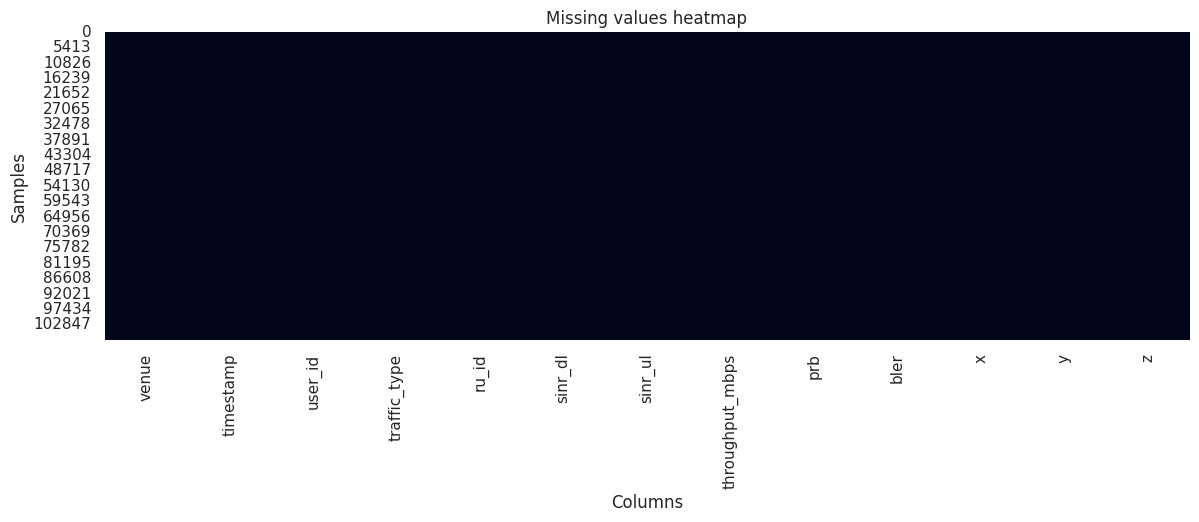

In [ ]:
# Plot missing values as a heatmap
# This helps identify whether some features are systematically absent
plt.figure(figsize=(14, 4))
sns.heatmap(raw_df.isna(), cbar=False)
plt.title('Missing values heatmap')
plt.xlabel('Columns')
plt.ylabel('Samples')
plt.show()

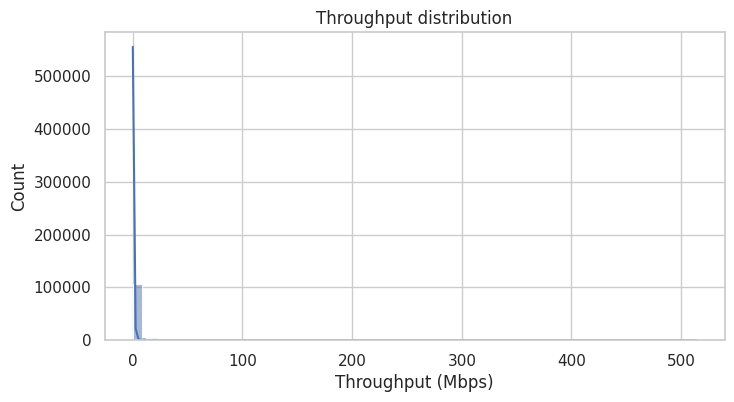

In [ ]:
# Distribution of throughput values
# This is useful to understand whether the target is skewed and whether some models may be sensitive to extreme values
plt.figure(figsize=(8, 4))
sns.histplot(raw_df[COL_THROUGHPUT], bins=60, kde=True)
plt.title('Throughput distribution')
plt.xlabel('Throughput (Mbps)')
plt.show()

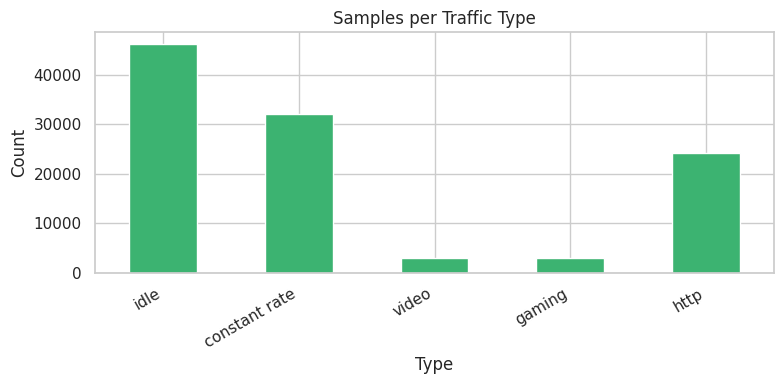

In [ ]:
# Traffic type distribution.
# This shows whether some traffic types are much more frequent than others.
TRAFFIC_LABELS = {0:'off',1:'idle',2:'constant rate',3:'video',4:'gaming',5:'http'}
counts = raw_df[COL_TRAFFIC_TYPE].value_counts().sort_index()
counts.index = [TRAFFIC_LABELS.get(int(i), str(i)) for i in counts.index]
fig, ax = plt.subplots(figsize=(8, 4))
counts.plot(kind='bar', ax=ax, color='mediumseagreen', edgecolor='white')
ax.set(title='Samples per Traffic Type', xlabel='Type', ylabel='Count')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

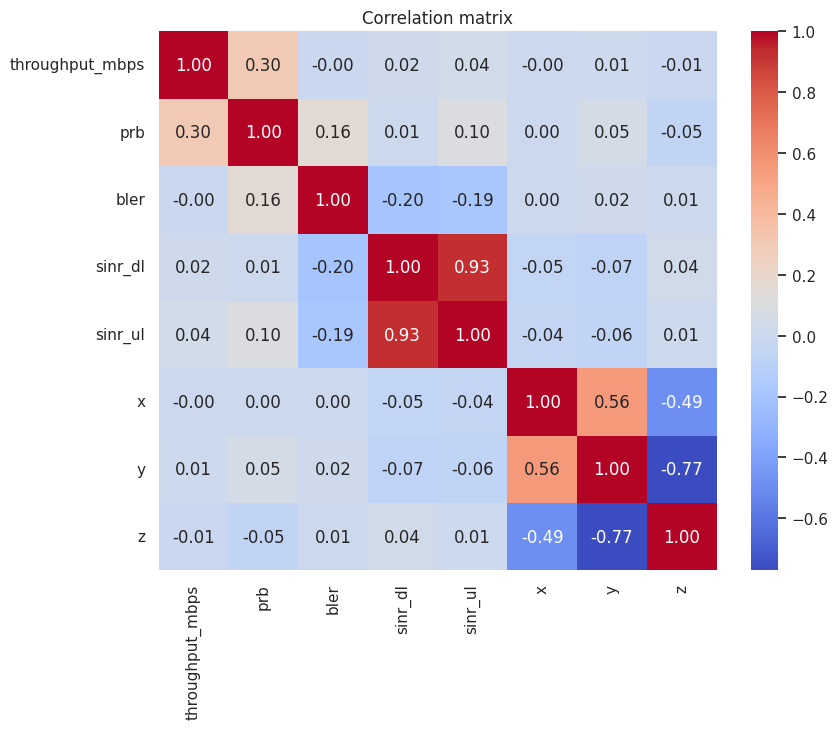

In [ ]:
# Correlation matrix for the numeric columns
# This is a quick way to see possible redundancy and strong relationships with throughput
numeric_cols = [COL_THROUGHPUT, COL_PRB, COL_BLER, COL_SINR_DL, COL_SINR_UL, COL_X, COL_Y, COL_Z]
plt.figure(figsize=(9, 7))
sns.heatmap(raw_df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation matrix')
plt.show()

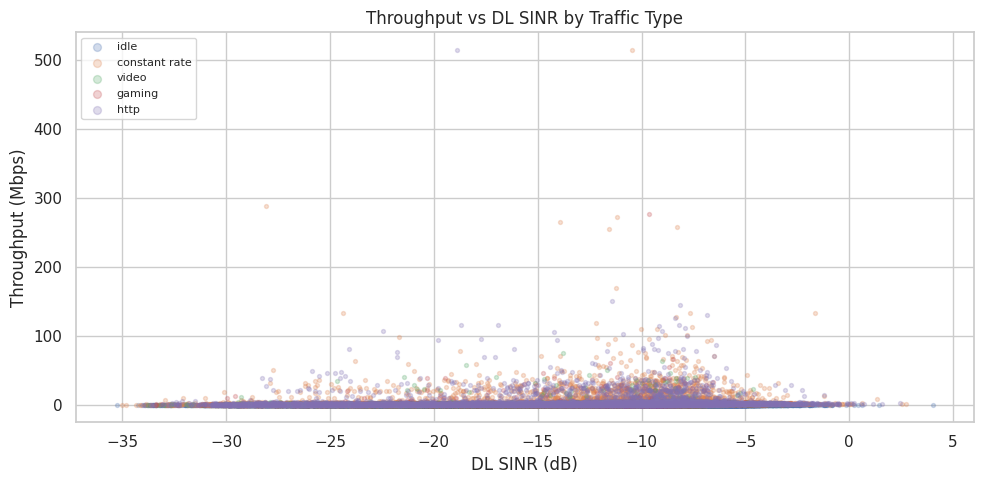

In [ ]:
# Scatter plot: throughput vs downlink SINR
# This can reveal whether better radio quality tends to imply higher throughput
fig, ax = plt.subplots(figsize=(10, 5))
for tt, label in TRAFFIC_LABELS.items():
    sub = raw_df[raw_df[COL_TRAFFIC_TYPE] == tt]
    if len(sub):
        ax.scatter(sub[COL_SINR_DL], sub[COL_THROUGHPUT], alpha=0.25, s=8, label=label)
ax.set(xlabel='DL SINR (dB)', ylabel='Throughput (Mbps)',
       title='Throughput vs DL SINR by Traffic Type')
ax.legend(markerscale=2, loc='upper left', fontsize=8)
plt.tight_layout(); plt.show()

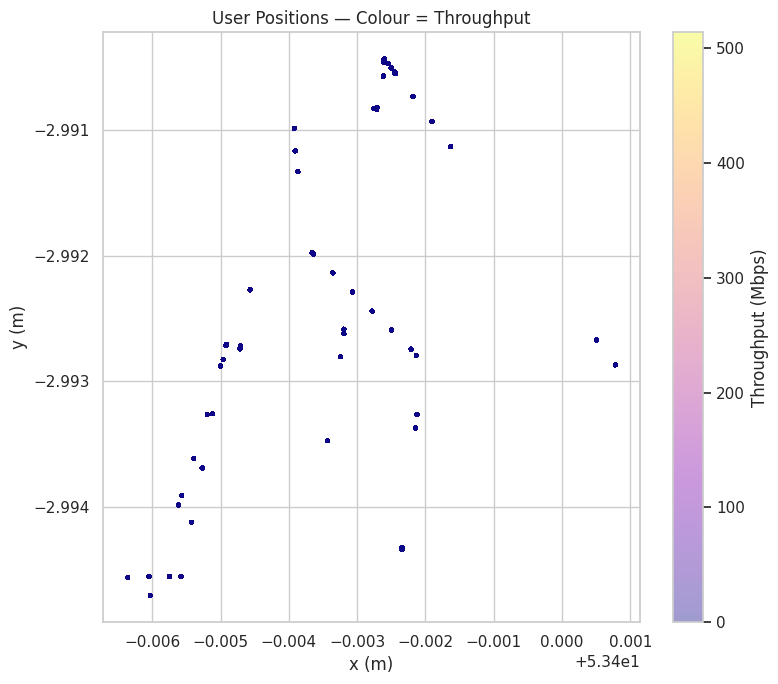

In [ ]:
# Spatial visualization of user positions
# This can show whether some areas of the arena are associated with different throughput levels
fig, ax = plt.subplots(figsize=(8, 7))
sc = ax.scatter(raw_df[COL_X], raw_df[COL_Y],
                c=raw_df[COL_THROUGHPUT], cmap='plasma', s=5, alpha=0.4)
plt.colorbar(sc, ax=ax, label='Throughput (Mbps)')
ax.set(title='User Positions — Colour = Throughput', xlabel='x (m)', ylabel='y (m)')
plt.tight_layout(); plt.show()

### EDA Conclusions

Based on the plots above:

1. **Target variable (throughput):** Highly right-skewed as most samples have near-zero throughput, but a small fraction reach > 10 Mbps. This justifies using robust non-linear models such as **Random Forest** and **Neural Network** rather than linear regression.

2. **Informative features:** `PRB` and `SINR_DL` show the clearest positive correlation with throughput (confirmed in the correlation heatmap). `BLER` is negatively correlated, higher error rate ⟹ lower throughput. These are the strongest predictors.

3. **Traffic type:** Throughput differs significantly across traffic classes. Including `traffic_type` as a categorical feature is important.

4. **Position (x, y, z):** Users appear clustered in a small geographic area (dense arena deployment). The `z` coordinate varies more than `x` or `y`, likely reflecting different floors.

5. **Operator features:** The aggregated statistics (mean/max/std throughput of operator devices with the same traffic type) are not constant and show variability across timestamps. This suggests they carry signal relevant for prediction.

6. **No missing values** were detected, so imputation will have no effect in practice but the pipeline includes it for robustness either way.


## 6. Preprocessing and feature engineering

In [ ]:
# Build the prediction dataset
prepared_df, feature_columns = prepare_dataset(raw_df, measurement_device_count=X)

target_column = COL_THROUGHPUT
user_id_column = COL_USER_ID
timestamp_column = COL_TIMESTAMP

print('Prepared dataset shape:', prepared_df.shape)
print('Number of features:', len(feature_columns))
print('Features used:')
for col in feature_columns:
    print('-', col)

prepared_df.head()

Prepared dataset shape: (98400, 19)
Number of features: 15
Features used:
- prb
- bler
- sinr_dl
- sinr_ul
- x
- y
- z
- operator_same_type_count
- operator_same_type_mean_throughput
- operator_same_type_median_throughput
- operator_same_type_max_throughput
- operator_same_type_min_throughput
- operator_same_type_std_throughput
- traffic_type
- ru_id


,venue,timestamp,user_id,traffic_type,ru_id,sinr_dl,sinr_ul,throughput_mbps,prb,bler,x,y,z,operator_same_type_count,operator_same_type_mean_throughput,operator_same_type_median_throughput,operator_same_type_max_throughput,operator_same_type_min_throughput,operator_same_type_std_throughput
0,ACC Arena,1970-01-01 00:00:00.000001215,20,1,15,-9.368493,-11.096085,0.000,0,0.000000,53.396342,-2.991977,3.660437,6.0,0.000000,0.00,0.000,0.0,0.000000
1,ACC Arena,1970-01-01 00:00:00.000001215,21,1,32,-11.446065,-9.948171,0.000,0,0.000000,53.395285,-2.992742,0.746955,6.0,0.000000,0.00,0.000,0.0,0.000000
2,ACC Arena,1970-01-01 00:00:00.000001215,22,5,33,-5.889293,-8.575525,0.352,10,0.000001,53.397389,-2.990571,-1.339999,7.0,0.731429,0.32,2.688,0.0,1.013181
3,ACC Arena,1970-01-01 00:00:00.000001215,23,1,16,-16.572642,-17.110671,0.000,0,0.000000,53.396933,-2.992290,3.660070,6.0,0.000000,0.00,0.000,0.0,0.000000
4,ACC Arena,1970-01-01 00:00:00.000001215,24,2,22,-30.197367,-29.926339,0.560,15,0.441300,53.395089,-2.992707,3.580986,6.0,0.560000,0.00,2.320,0.0,0.957330


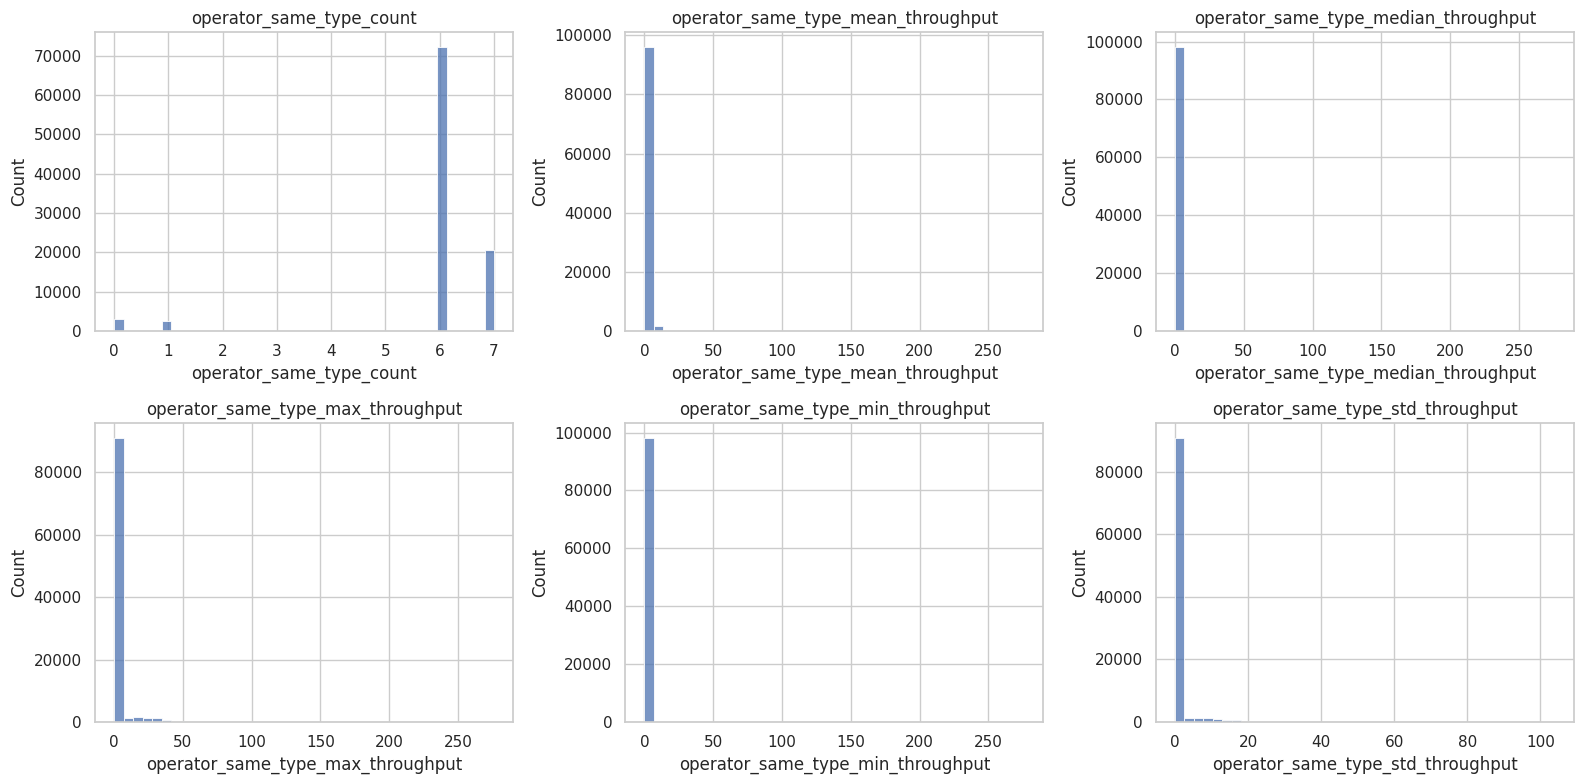

In [ ]:
# Visualize the distributions of the operator features
# This helps confirm that the extra engineered features are not constant or broken
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.ravel()
for ax, col in zip(axes, OPERATOR_FEATURE_COLS):
    sns.histplot(prepared_df[col], bins=40, kde=False, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

## 7. Train/test split

In [ ]:
# Split each user chronologically
# This is more realistic than a random split because future samples should not be used to predict the past.
train_df, test_df = per_user_time_split(
    prepared_df,
    user_id_column=user_id_column,
    timestamp_column=timestamp_column,
    test_fraction=TEST_FRACTION,
)

# Keep only users suitable for local/FL comparisons
train_df, test_df, eligible_users = filter_eligible_users(
    train_df,
    test_df,
    user_id_column=user_id_column,
    local_min_samples=LOCAL_MIN_SAMPLES,
)

print('Train shape:', train_df.shape)
print('Test shape:', test_df.shape)
print('Eligible users for local/FL experiments:', len(eligible_users))

Train shape: (78600, 19)
Test shape: (19800, 19)
Eligible users for local/FL experiments: 200


### Why TimeSeriesSplit for cross-validation?

The assignment asks for **hyperparameter tuning with cross-validation**.
Because this dataset has a temporal structure, a standard random k-fold split would mix older and newer samples, creating data leakage.

For this reason, the notebook uses **TimeSeriesSplit**, which preserves ordering and better simulates a realistic forecasting scenario: training on older samples and validating on newer ones.


## 8. Centralized models: Random Forest and MLP

In [ ]:
# Generic helper to train and evaluate a scikit-learn regressor
# Avoids duplicating code for Random Forest and MLP

def evaluate_sklearn_regressor(name, estimator, param_grid, train_frame, test_frame,
                               feature_columns, target_column, categorical_columns):
    # Separate numeric and categorical features.
    numeric_columns = [col for col in feature_columns if col not in categorical_columns]

    # Build preprocessing + model pipeline.
    preprocessor = build_preprocessor(numeric_columns, categorical_columns)
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('model', estimator),
    ])

    # Time-aware cross-validation for hyperparameter tuning
    start = time.perf_counter()
    splitter = TimeSeriesSplit(n_splits=min(3, len(train_frame) - 1))

    search = GridSearchCV(
        estimator=pipeline,
        param_grid=param_grid,
        scoring='neg_mean_absolute_error',
        cv=splitter,
        n_jobs=1,
        refit=True,
    )

    search.fit(train_frame[feature_columns], train_frame[target_column])
    best_pipeline = search.best_estimator_
    train_seconds = time.perf_counter() - start

    # Predict on the held-out test set.
    predictions = best_pipeline.predict(test_frame[feature_columns])
    metrics = regression_metrics(test_frame[target_column].to_numpy(), predictions)

    # Permutation importance is used as a simple explainability tool
    # It measures how much the error changes when a feature is shuffled
    importance = permutation_importance(
        best_pipeline,
        test_frame[feature_columns],
        test_frame[target_column],
        n_repeats=5,
        random_state=RANDOM_STATE,
        scoring='neg_mean_absolute_error',
    )

    feature_importance = {
        feature: float(score)
        for feature, score in sorted(
            zip(feature_columns, importance.importances_mean),
            key=lambda item: item[1],
            reverse=True,
        )
    }

    return {
        'name': name,
        'metrics': metrics,
        'train_seconds': train_seconds,
        'best_params': search.best_params_,
        'feature_importance': feature_importance,
        'model': best_pipeline,
    }

print('Centralized model helper ready.')

Centralized model helper ready.


In [ ]:
# Train Random Forest
rf_result = evaluate_sklearn_regressor(
    name='Random Forest',
    estimator=RandomForestRegressor(n_jobs=-1, random_state=RANDOM_STATE),
    param_grid={
        'model__n_estimators': [200, 300],
        'model__max_depth': [12, 16, None],
        'model__min_samples_leaf': [1, 2, 4],
    },
    train_frame=train_df,
    test_frame=test_df,
    feature_columns=feature_columns,
    target_column=target_column,
    categorical_columns=CATEGORICAL_COLS,
)

print('Random Forest done.')
print(rf_result['metrics'])
print('Best params:', rf_result['best_params'])
print('Train time:', rf_result['train_seconds'])

Random Forest done.
{'mae': 0.6831503745669184, 'mse': 20.983775311569673, 'rmse': 4.580805094256868, 'r2': 0.01547115012744349}
Best params: {'model__max_depth': 12, 'model__min_samples_leaf': 4, 'model__n_estimators': 200}
Train time: 3508.1668231119993


In [ ]:
# Train MLP (Neural Network)
mlp_result = evaluate_sklearn_regressor(
    name='MLP',
    estimator=MLPRegressor(
        activation='relu',
        learning_rate_init=1e-3,
        max_iter=200,
        early_stopping=True,
        random_state=RANDOM_STATE,
    ),
    param_grid={
        'model__hidden_layer_sizes': [(128, 64), (256, 128)],
        'model__alpha': [1e-4, 1e-3],
        'model__learning_rate_init': [1e-3, 5e-4],
    },
    train_frame=train_df,
    test_frame=test_df,
    feature_columns=feature_columns,
    target_column=target_column,
    categorical_columns=CATEGORICAL_COLS,
)

print('MLP done.')
print(mlp_result['metrics'])
print('Best params:', mlp_result['best_params'])
print('Train time:', mlp_result['train_seconds'])

MLP done.
{'mae': 0.6610114068265883, 'mse': 20.068516142588322, 'rmse': 4.479789743122809, 'r2': 0.05841380670820129}
Best params: {'model__alpha': 0.0001, 'model__hidden_layer_sizes': (128, 64), 'model__learning_rate_init': 0.001}
Train time: 370.68040284199924


In [ ]:
# Compare centralized models in a single table
centralized_comparison = pd.DataFrame([
    {
        'model': rf_result['name'],
        **rf_result['metrics'],
        'train_seconds': rf_result['train_seconds'],
    },
    {
        'model': mlp_result['name'],
        **mlp_result['metrics'],
        'train_seconds': mlp_result['train_seconds'],
    },
])
centralized_comparison

,model,mae,mse,rmse,r2,train_seconds
0,Random Forest,0.683150,20.983775,4.580805,0.015471,3508.166823
1,MLP,0.661011,20.068516,4.479790,0.058414,370.680403


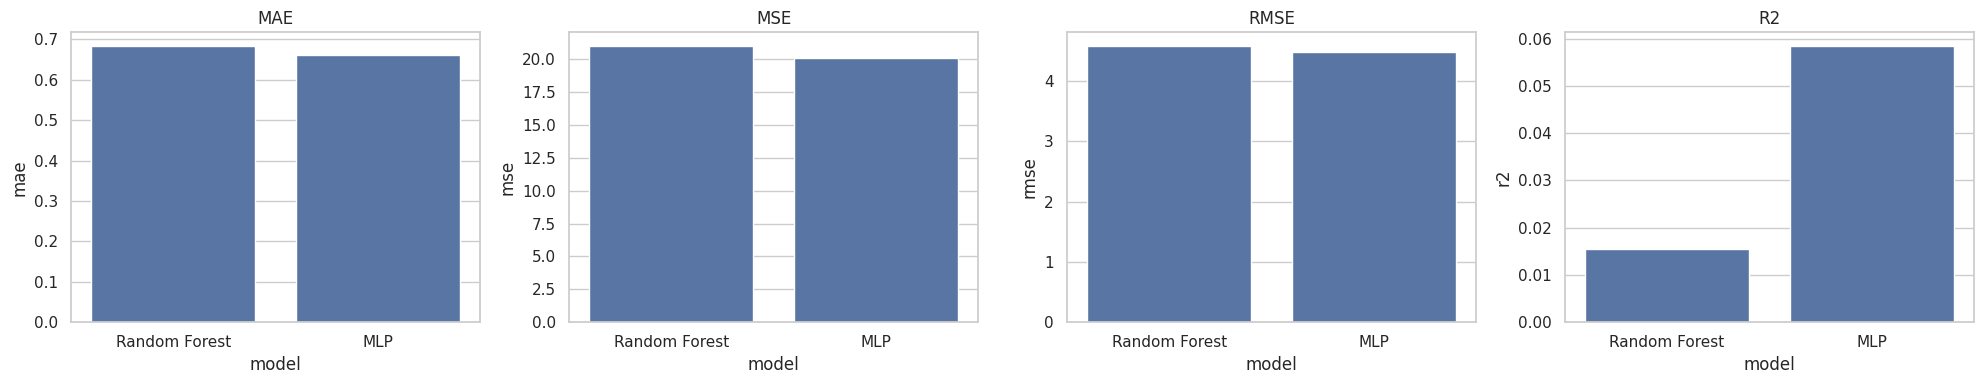

In [ ]:
# Plot the centralized metrics for visual comparison
metrics_to_plot = ['mae', 'mse', 'rmse', 'r2']
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
for ax, metric_name in zip(axes, metrics_to_plot):
    sns.barplot(data=centralized_comparison, x='model', y=metric_name, ax=ax)
    ax.set_title(metric_name.upper())
plt.tight_layout()
plt.show()

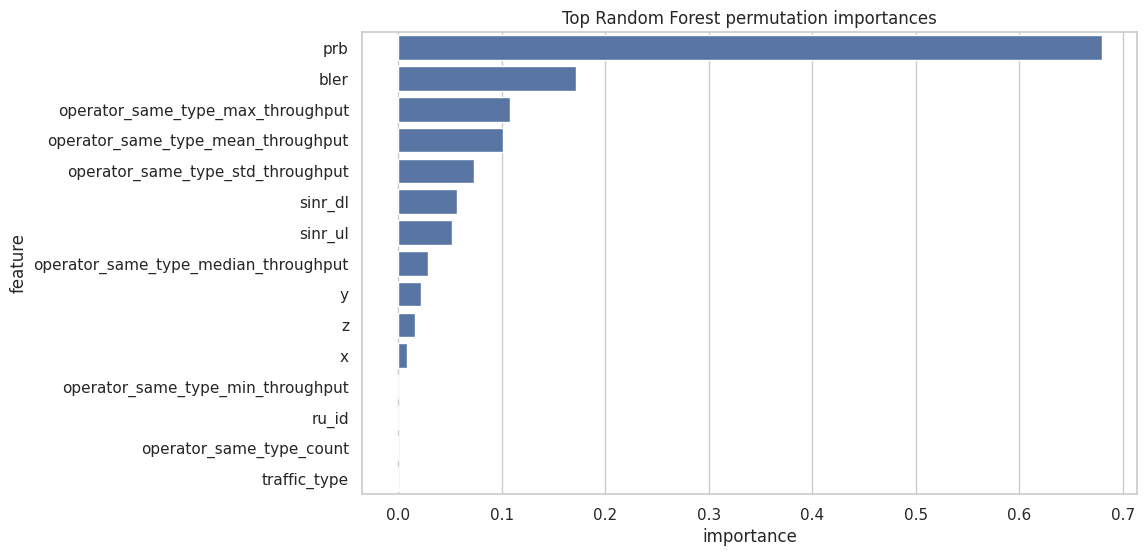

In [ ]:
# Plot Random Forest feature importances
rf_importance_df = pd.DataFrame({
    'feature': list(rf_result['feature_importance'].keys()),
    'importance': list(rf_result['feature_importance'].values()),
}).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(data=rf_importance_df, y='feature', x='importance')
plt.title('Top Random Forest permutation importances')
plt.show()

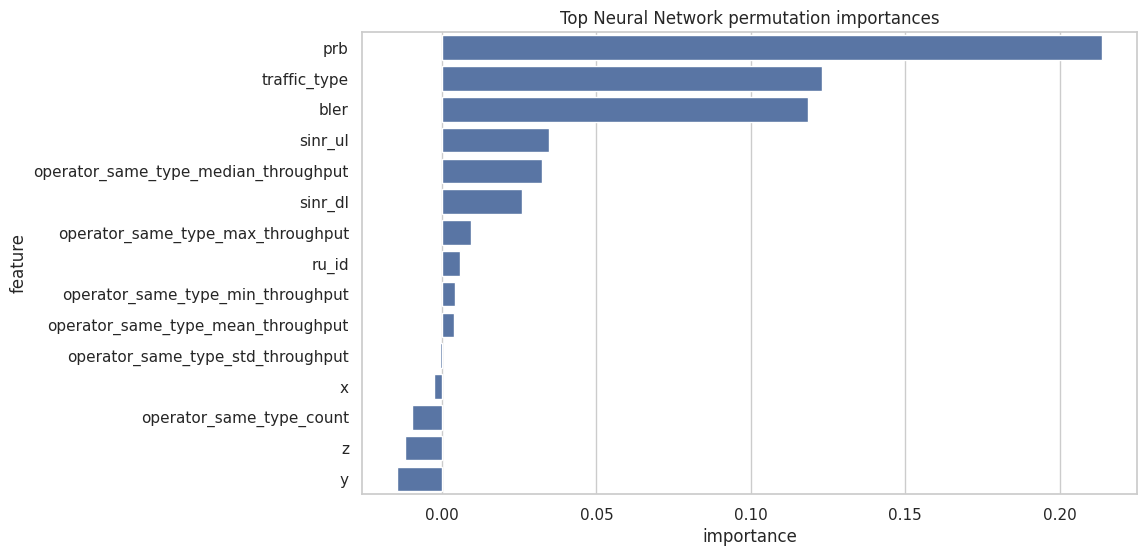

In [ ]:
# Plot Neural Network feature importances

mlp_importance_df = pd.DataFrame({
    'feature': list(mlp_result['feature_importance'].keys()),
    'importance': list(mlp_result['feature_importance'].values()),
}).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(data=mlp_importance_df, y='feature', x='importance')
plt.title('Top Neural Network permutation importances')
plt.show()

## 9. Federated Learning (FedAvg)

In [ ]:
# -----------------------------
# PyTorch model for Goal 3
# -----------------------------

class TorchMLPRegressor(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 1),
        )

    def forward(self, x):
        return self.network(x).squeeze(-1)


def train_local_model(model, train_x, train_y, epochs, learning_rate=1e-3):
    # Standard supervised training loop with MSE loss
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    loss_fn = nn.MSELoss()

    loader = DataLoader(
        TensorDataset(torch.from_numpy(train_x), torch.from_numpy(train_y.astype(np.float32))),
        batch_size=min(128, len(train_x)),
        shuffle=True,
    )

    model.train()
    for _ in range(epochs):
        for batch_x, batch_y in loader:
            optimizer.zero_grad()
            prediction = model(batch_x)
            loss = loss_fn(prediction, batch_y)
            loss.backward()
            optimizer.step()

    return model


def predict_torch(model, test_x):
    model.eval()
    with torch.no_grad():
        return model(torch.from_numpy(test_x)).cpu().numpy()


def average_state_dicts(state_dicts, weights):
    # Weighted FedAvg aggregation
    total_weight = float(sum(weights))
    averaged = OrderedDict()
    for key in state_dicts[0]:
        averaged[key] = sum(
            state[key] * (weight / total_weight)
            for state, weight in zip(state_dicts, weights)
        )
    return averaged

print('Torch FL helpers created.')

Torch FL helpers created.


In [ ]:
# Main federated evaluation function
def evaluate_federated_mlp(train_frame, test_frame, feature_columns, target_column,
                           user_id_column, categorical_columns, rounds,
                           local_epochs, local_min_samples, random_state):
    torch.manual_seed(random_state)
    np.random.seed(random_state)

    # Fit a shared feature preprocessor using all train data
    numeric_columns = [col for col in feature_columns if col not in categorical_columns]
    preprocessor = build_preprocessor(numeric_columns, categorical_columns)
    preprocessor.fit(train_frame[feature_columns])

    def transform_features(frame):
        transformed = preprocessor.transform(frame[feature_columns])
        if hasattr(transformed, 'toarray'):
            transformed = transformed.toarray()
        return transformed.astype(np.float32)

    train_x_all = transform_features(train_frame)
    test_x = transform_features(test_frame)

    # Scale the target for neural-network training stability
    target_scaler = StandardScaler()
    train_y_all = train_frame[target_column].to_numpy(dtype=np.float32).reshape(-1, 1)
    target_scaler.fit(train_y_all)
    train_y_all_scaled = target_scaler.transform(train_y_all).reshape(-1).astype(np.float32)
    test_y = test_frame[target_column].to_numpy(dtype=np.float32)

    input_dim = train_x_all.shape[1]

    # Build FL clients: one client per eligible user
    clients = {}
    for user_id, client_frame in train_frame.groupby(user_id_column):
        if len(client_frame) < local_min_samples:
            continue

        client_test_frame = test_frame.loc[test_frame[user_id_column] == user_id].copy()
        if client_test_frame.empty:
            continue

        client_x = transform_features(client_frame)
        client_y = target_scaler.transform(
            client_frame[target_column].to_numpy(dtype=np.float32).reshape(-1, 1)
        ).reshape(-1).astype(np.float32)

        clients[user_id] = (client_x, client_y)

    if not clients:
        raise ValueError('No client has enough samples for federated training.')

    # -----------------------------
    # Centralized PyTorch MLP baseline
    # -----------------------------
    centralized_model = TorchMLPRegressor(input_dim=input_dim)
    start = time.perf_counter()
    centralized_model = train_local_model(
        model=centralized_model,
        train_x=train_x_all,
        train_y=train_y_all_scaled,
        epochs=max(local_epochs * rounds, 1),
        learning_rate=1e-3,
    )
    centralized_train_seconds = time.perf_counter() - start

    centralized_predictions = predict_torch(centralized_model, test_x).reshape(-1, 1)
    centralized_predictions = target_scaler.inverse_transform(centralized_predictions).reshape(-1)
    centralized_metrics = regression_metrics(test_y, centralized_predictions)

    # -----------------------------
    # FedAvg global model
    # -----------------------------
    global_model = TorchMLPRegressor(input_dim=input_dim)
    round_metrics = []

    start = time.perf_counter()
    for round_idx in range(rounds):
        local_state_dicts = []
        local_weights = []
        global_state = global_model.state_dict()

        # Each client starts from the current global model, trains locally, and then sends its updated weights
        for client_x, client_y in clients.values():
            local_model = TorchMLPRegressor(input_dim=input_dim)
            local_model.load_state_dict(copy.deepcopy(global_state))
            local_model = train_local_model(
                model=local_model,
                train_x=client_x,
                train_y=client_y,
                epochs=local_epochs,
                learning_rate=1e-3,
            )
            local_state_dicts.append(local_model.state_dict())
            local_weights.append(len(client_x))

        averaged_state = average_state_dicts(local_state_dicts, local_weights)
        global_model.load_state_dict(averaged_state)

        # Track performance after each round for the convergence curve
        round_predictions = predict_torch(global_model, test_x).reshape(-1, 1)
        round_predictions = target_scaler.inverse_transform(round_predictions).reshape(-1)
        round_metrics.append(regression_metrics(test_y, round_predictions))

    federated_train_seconds = time.perf_counter() - start

    global_predictions = predict_torch(global_model, test_x).reshape(-1, 1)
    global_predictions = target_scaler.inverse_transform(global_predictions).reshape(-1)
    global_metrics = regression_metrics(test_y, global_predictions)

    # -----------------------------
    # Local-only baselines
    # -----------------------------
    local_metrics = {}
    pooled_truth = []
    pooled_predictions = []

    for user_id, (client_x, _) in clients.items():
        client_train_frame = train_frame.loc[train_frame[user_id_column] == user_id].copy()
        client_test_frame = test_frame.loc[test_frame[user_id_column] == user_id].copy()

        # Each local model gets its own target scaler
        local_target_scaler = StandardScaler()
        local_train_y = client_train_frame[target_column].to_numpy(dtype=np.float32).reshape(-1, 1)
        local_target_scaler.fit(local_train_y)
        local_train_y_scaled = local_target_scaler.transform(local_train_y).reshape(-1).astype(np.float32)

        client_test_x = transform_features(client_test_frame)
        client_test_y = client_test_frame[target_column].to_numpy(dtype=np.float32)

        local_model = TorchMLPRegressor(input_dim=input_dim)
        local_model = train_local_model(
            model=local_model,
            train_x=client_x,
            train_y=local_train_y_scaled,
            epochs=max(local_epochs * rounds, 1),
            learning_rate=1e-3,
        )

        local_predictions = predict_torch(local_model, client_test_x).reshape(-1, 1)
        local_predictions = local_target_scaler.inverse_transform(local_predictions).reshape(-1)

        local_metrics[str(user_id)] = regression_metrics(client_test_y, local_predictions)
        pooled_truth.append(client_test_y)
        pooled_predictions.append(local_predictions)

    local_pooled_metrics = regression_metrics(np.concatenate(pooled_truth), np.concatenate(pooled_predictions))
    local_average_metrics = {
        f'avg_{key}': float(mean(metric[key] for metric in local_metrics.values()))
        for key in ['mae', 'mse', 'rmse', 'r2']
    }

    return {
        'centralized_metrics': centralized_metrics,
        'centralized_train_seconds': centralized_train_seconds,
        'global_metrics': global_metrics,
        'local_pooled_metrics': local_pooled_metrics,
        'local_average_metrics': local_average_metrics,
        'local_metrics': local_metrics,
        'train_seconds': federated_train_seconds,
        'num_clients': len(clients),
        'round_metrics': round_metrics,
    }

print('Federated evaluation function ready.')

Federated evaluation function ready.


In [ ]:
# Run federated learning evaluation
fed_result = evaluate_federated_mlp(
    train_frame=train_df,
    test_frame=test_df,
    feature_columns=feature_columns,
    target_column=target_column,
    user_id_column=user_id_column,
    categorical_columns=CATEGORICAL_COLS,
    rounds=FEDERATED_ROUNDS,
    local_epochs=LOCAL_EPOCHS,
    local_min_samples=LOCAL_MIN_SAMPLES,
    random_state=RANDOM_STATE,
)

print('Federated evaluation completed.')
print('Number of clients:', fed_result['num_clients'])
print('Global FedAvg metrics:', fed_result['global_metrics'])

Federated evaluation completed.
Number of clients: 200
Global FedAvg metrics: {'mae': 0.613872517508577, 'mse': 22.669896058317025, 'rmse': 4.761291427576874, 'r2': -0.06363924882341299}


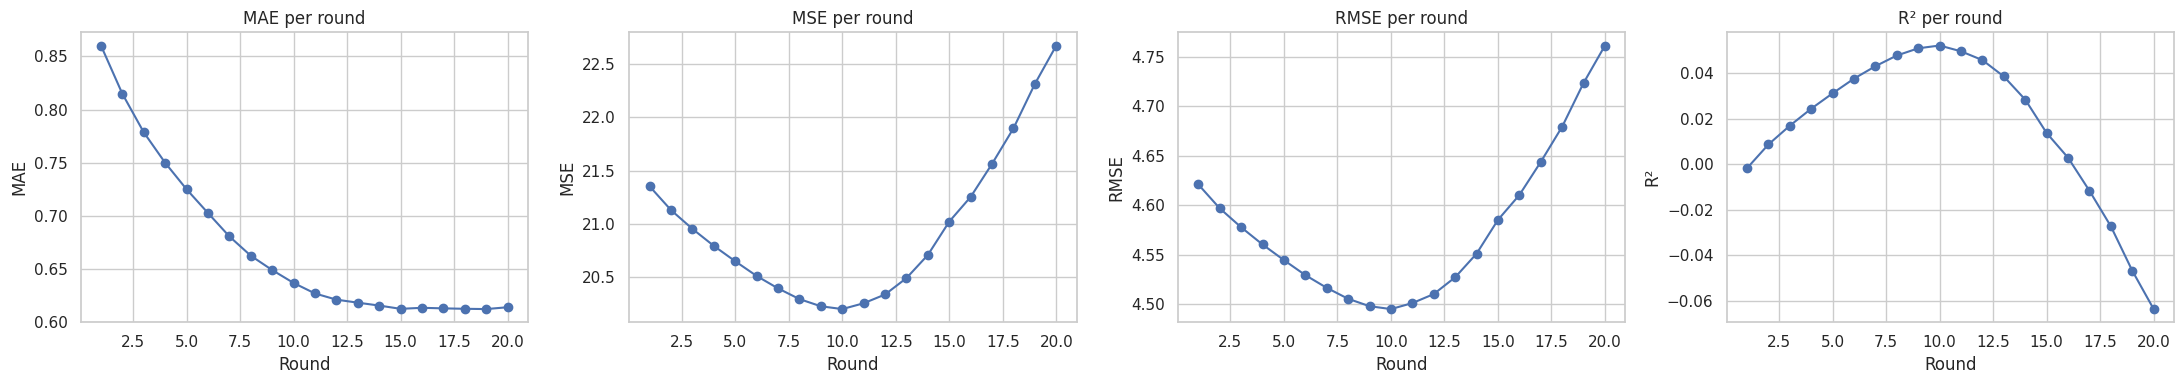

In [ ]:
# Convergence curve: track all four metrics over FL rounds
# This gives a fuller picture of how the global model improves each round

round_mae  = [item['mae']  for item in fed_result['round_metrics']]
round_mse  = [item['mse']  for item in fed_result['round_metrics']]
round_rmse = [item['rmse'] for item in fed_result['round_metrics']]
round_r2   = [item['r2']   for item in fed_result['round_metrics']]

rounds_axis = range(1, len(round_rmse) + 1)

fig, axes = plt.subplots(1, 4, figsize=(22, 4))
for ax, values, title in zip(
    axes,
    [round_mae, round_mse, round_rmse, round_r2],
    ['MAE per round', 'MSE per round', 'RMSE per round', 'R² per round']
):
    ax.plot(rounds_axis, values, marker='o')
    ax.set_title(title)
    ax.set_xlabel('Round')
    ax.set_ylabel(title.split()[0])
plt.tight_layout()
plt.show()


In [ ]:
# Goal 3 comparison table.
# The assignment requires comparing:
#   1. A centralized model trained on all data (we include BOTH RF and MLP)
#   2. Federated MLP (FedAvg global model)
#   3. Local MLP – pooled evaluation on the full test set
#   4. Local MLP – per-client average metrics

goal3_comparison = pd.DataFrame([
    {
        'model': 'Centralized Random Forest',
        **rf_result['metrics'],
        'train_seconds': rf_result['train_seconds'],
    },
    {
        'model': 'Centralized MLP (PyTorch, untuned)',
        **fed_result['centralized_metrics'],
        'train_seconds': fed_result['centralized_train_seconds'],
    },
    {
        'model': 'Federated MLP (FedAvg)',
        **fed_result['global_metrics'],
        'train_seconds': fed_result['train_seconds'],
    },
    {
        'model': 'Local MLP (pooled)',
        **fed_result['local_pooled_metrics'],
        'train_seconds': np.nan,
    },
    {
        'model': 'Local MLP (avg per client)',
        'mae':  fed_result['local_average_metrics']['avg_mae'],
        'mse':  fed_result['local_average_metrics']['avg_mse'],
        'rmse': fed_result['local_average_metrics']['avg_rmse'],
        'r2':   fed_result['local_average_metrics']['avg_r2'],
        'train_seconds': np.nan,
    },
])

goal3_comparison


,model,mae,mse,rmse,r2,train_seconds
0,Centralized Random Forest,0.683150,20.983775,4.580805,0.015471,3508.166823
1,Centralized MLP,0.795968,20.992426,4.581749,0.015065,111.098010
2,Federated MLP (FedAvg),0.613873,22.669896,4.761291,-0.063639,134.720930
3,Local MLP (pooled),0.824879,21.776926,4.666575,-0.021742,NaN
4,Local MLP (avg per client),0.824879,21.776926,2.460375,-1.878224,NaN


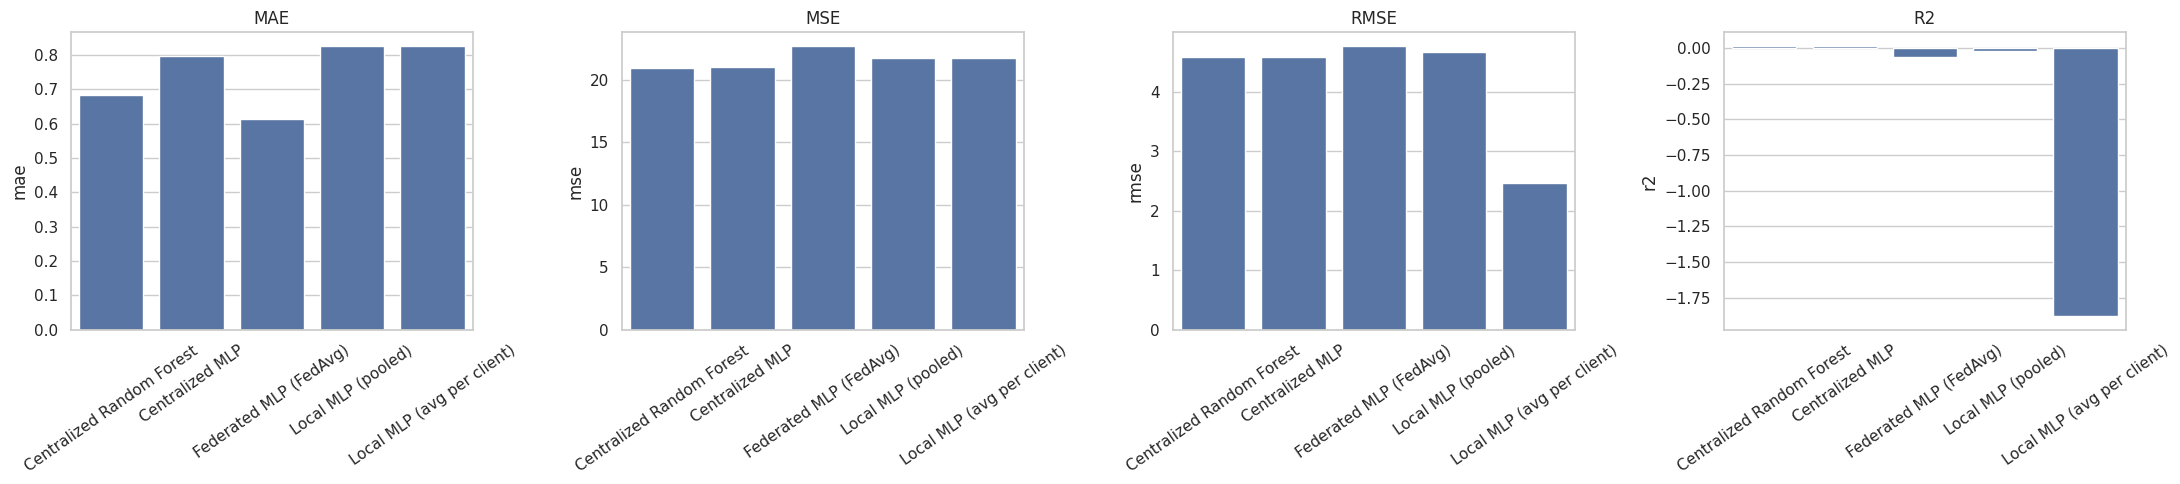

In [ ]:
# Visual comparison of Goal 3 models (all five rows)
fig, axes = plt.subplots(1, 4, figsize=(22, 5))
for ax, metric_name in zip(axes, ['mae', 'mse', 'rmse', 'r2']):
    # Use a subset that has numeric values for this metric
    plot_data = goal3_comparison.dropna(subset=[metric_name])
    sns.barplot(data=plot_data, x='model', y=metric_name, ax=ax)
    ax.set_title(metric_name.upper())
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=35)
plt.tight_layout()
plt.show()


## 10. Experiment with different values of X

In [ ]:
# Sensitivity experiment: how does model performance change with different values of X?
#
# For each value of X we:
#   1. Re-build the dataset (operator features change with X).
#   2. Re-split train/test chronologically.
#   3. Train both Random Forest and MLP with the same hyper-parameter grids.
#   4. Record all four metrics for both models.

x_sweep_rows = []

for x_value in X_VALUES:
    print(f'\n--- X = {x_value} ---')

    # 1. Build dataset for this value of X.
    sweep_df, sweep_features = prepare_dataset(raw_df, measurement_device_count=x_value)

    # 2. Chronological split
    sweep_train, sweep_test = per_user_time_split(
        sweep_df, COL_USER_ID, COL_TIMESTAMP, TEST_FRACTION
    )
    sweep_train, sweep_test, _ = filter_eligible_users(
        sweep_train, sweep_test, COL_USER_ID, LOCAL_MIN_SAMPLES
    )

    # 3a. Random Forest
    rf_x = evaluate_sklearn_regressor(
        name='Random Forest',
        estimator=RandomForestRegressor(n_jobs=-1, random_state=RANDOM_STATE),
        param_grid={
            'model__n_estimators': [200],
            'model__max_depth': [12, None],
            'model__min_samples_leaf': [2],
        },
        train_frame=sweep_train,
        test_frame=sweep_test,
        feature_columns=sweep_features,
        target_column=COL_THROUGHPUT,
        categorical_columns=CATEGORICAL_COLS,
    )

    # 3b. MLP
    mlp_x = evaluate_sklearn_regressor(
        name='MLP',
        estimator=MLPRegressor(
            activation='relu', max_iter=200,
            early_stopping=True, random_state=RANDOM_STATE
        ),
        param_grid={
            'model__hidden_layer_sizes': [(128, 64)],
            'model__alpha': [1e-4, 1e-3],
            'model__learning_rate_init': [1e-3],
        },
        train_frame=sweep_train,
        test_frame=sweep_test,
        feature_columns=sweep_features,
        target_column=COL_THROUGHPUT,
        categorical_columns=CATEGORICAL_COLS,
    )

    x_sweep_rows.append({
        'X': x_value,
        'rf_mae':  rf_x['metrics']['mae'],  'rf_mse':  rf_x['metrics']['mse'],
        'rf_rmse': rf_x['metrics']['rmse'], 'rf_r2':   rf_x['metrics']['r2'],
        'mlp_mae': mlp_x['metrics']['mae'], 'mlp_mse': mlp_x['metrics']['mse'],
        'mlp_rmse':mlp_x['metrics']['rmse'],'mlp_r2':  mlp_x['metrics']['r2'],
    })
    print(f'  RF  → MAE={rf_x["metrics"]["mae"]:.4f}  RMSE={rf_x["metrics"]["rmse"]:.4f}  R²={rf_x["metrics"]["r2"]:.4f}')
    print(f'  MLP → MAE={mlp_x["metrics"]["mae"]:.4f}  RMSE={mlp_x["metrics"]["rmse"]:.4f}  R²={mlp_x["metrics"]["r2"]:.4f}')

x_sweep_df = pd.DataFrame(x_sweep_rows)
print('\nX-sweep complete.')
x_sweep_df



--- X = 3 ---
  RF  → MAE=0.6843  RMSE=4.7942  R²=0.0373
  MLP → MAE=0.7073  RMSE=4.7229  R²=0.0657

--- X = 5 ---
  RF  → MAE=0.7013  RMSE=4.8347  R²=0.0287
  MLP → MAE=0.7316  RMSE=4.7053  R²=0.0800

--- X = 10 ---
  RF  → MAE=0.7041  RMSE=4.8627  R²=0.0317
  MLP → MAE=0.6550  RMSE=4.7501  R²=0.0760

--- X = 20 ---
  RF  → MAE=0.6897  RMSE=4.6341  R²=-0.0076
  MLP → MAE=0.6610  RMSE=4.4798  R²=0.0584

X-sweep complete.


,X,rf_mae,rf_mse,rf_rmse,rf_r2,mlp_mae,mlp_mse,mlp_rmse,mlp_r2
0,3,0.684266,22.984179,4.794182,0.037292,0.707278,22.305501,4.722870,0.065718
1,5,0.701341,23.374519,4.834720,0.028670,0.731567,22.139519,4.705265,0.079990
2,10,0.704086,23.645885,4.862704,0.031706,0.654997,22.563065,4.750059,0.076048
3,20,0.689653,21.474758,4.634087,-0.007565,0.661011,20.068516,4.479790,0.058414


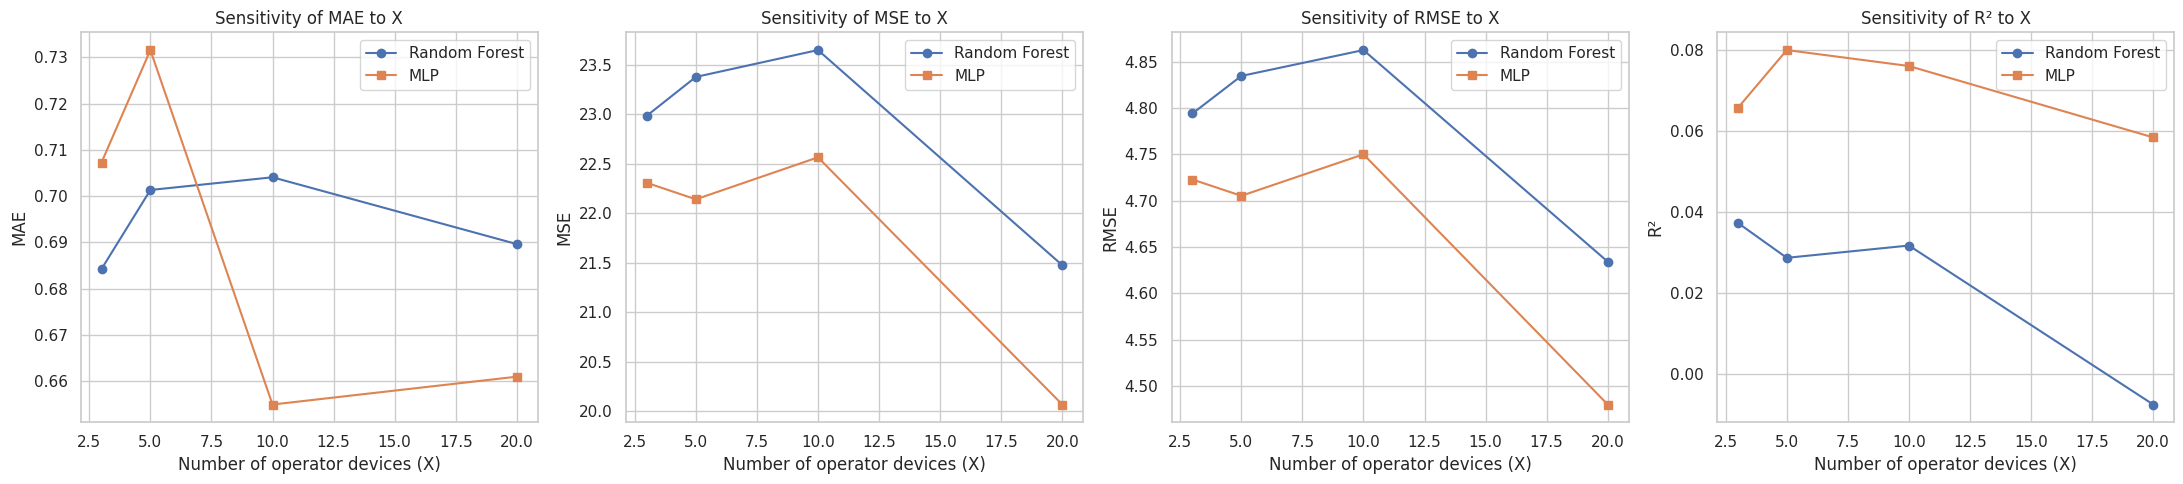

In [ ]:
# Plot the sensitivity of both models to X across all four metrics
fig, axes = plt.subplots(1, 4, figsize=(22, 5))

plot_specs = [
    ('rf_mae',  'mlp_mae',  'MAE'),
    ('rf_mse',  'mlp_mse',  'MSE'),
    ('rf_rmse', 'mlp_rmse', 'RMSE'),
    ('rf_r2',   'mlp_r2',   'R²'),
]

for ax, (rf_col, mlp_col, title) in zip(axes, plot_specs):
    ax.plot(x_sweep_df['X'], x_sweep_df[rf_col], marker='o', label='Random Forest')
    ax.plot(x_sweep_df['X'], x_sweep_df[mlp_col], marker='s', label='MLP')
    ax.set_title(f'Sensitivity of {title} to X')
    ax.set_xlabel('Number of operator devices (X)')
    ax.set_ylabel(title)
    ax.legend()

plt.tight_layout()
plt.show()


## 11. Save results

In [ ]:
# Save all main outputs to a single JSON file
results = {
    'config': {
        'X': X,
        'TEST_FRACTION': TEST_FRACTION,
        'RANDOM_STATE': RANDOM_STATE,
        'FEDERATED_ROUNDS': FEDERATED_ROUNDS,
        'LOCAL_EPOCHS': LOCAL_EPOCHS,
        'LOCAL_MIN_SAMPLES': LOCAL_MIN_SAMPLES,
        'X_VALUES': X_VALUES,
    },
    'centralized_rf': rf_result['metrics'],
    'centralized_mlp': mlp_result['metrics'],
    'centralized_comparison': centralized_comparison.to_dict(orient='records'),
    'goal3_comparison': goal3_comparison.to_dict(orient='records'),
    'x_sweep': x_sweep_df.to_dict(orient='records'),
}

output_path = Path('/content/project7_results_v2.json')
output_path.write_text(json.dumps(results, indent=2), encoding='utf-8')
print(f'Results saved to {output_path}')


Results saved to /content/project7_results_v2.json


In [ ]:
# Download the JSON results
from google.colab import files
files.download('/content/project7_results_v2.json')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Final Discussion and Conclusions

The workflow includes the ACC Arena dataset preprocessing, throughput regression, comparison between Random Forest and MLP models, the use of operator measurement devices, a sensitivity analysis over different values of `X`, and a Federated Learning simulation using FedAvg.

In the centralized setting, the MLP achieves the best overall performance. It obtains lower MAE and RMSE and a higher R² score than Random Forest. In addition, the MLP requires significantly less training time. This suggests that, for this subset and feature set, the MLP provides a better trade-off between prediction accuracy and computational cost.

However, the R² values are low for both centralized models. This indicates that user throughput prediction in a dense 5G scenario remains a difficult regression problem. The target variable is highly skewed, with many zero or very low throughput values and a small number of high-throughput peaks. As a consequence, the models can reduce the average prediction error, but they still struggle to explain the full variability of the throughput, especially in extreme cases.

The sensitivity analysis over `X` shows that increasing the number of operator measurement devices does not always improve performance. A larger `X` provides more contextual information about the network state, but it also changes the set of users excluded from the prediction dataset. Therefore, the effect of `X` is not monotonic and depends on the model, the metric considered, and the traffic-type coverage provided by the selected operator devices.

The Federated Learning experiment shows that FedAvg achieves the lowest MAE, meaning that it reduces the average absolute prediction error. However, it does not improve RMSE or R² compared with the best centralized model. This suggests that FedAvg performs reasonably well on common low-throughput cases, but still struggles with high-throughput outliers, which is consistent with its negative R². A likely cause is traffic-type heterogeneity across clients: each user's local model is trained almost exclusively on their own dominant traffic type, so averaging 200 such specialized models with FedAvg can wash out client-specific patterns that a single centralized model captures by seeing all traffic types jointly. Increasing LOCAL_EPOCHS or FEDERATED_ROUNDS, or weighting aggregation by traffic-type diversity rather than sample count alone, are possible directions to close this gap.

Overall, the results show that the proposed pipeline is valid and that MLP is the most effective centralized model in this experiment. Operator measurement devices provide useful network context, but their impact depends on the selected value of `X`. Federated Learning is a promising approach because it improves over purely local training in terms of MAE, but its benefits are limited in this setup and should be interpreted carefully.

Future improvements could include using a larger portion of the original dataset, testing additional values of `X`, improving traffic-type coverage among operator measurement devices, applying target transformations such as log-throughput, and tuning the PyTorch MLP architecture used in the Federated Learning experiments.